In [21]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models
from cellpose.io import imread
import os
import pandas as pd
import skimage
import scipy

# Align suffix of corrected masks & Scale Back to 2720

In [22]:
gt_hela = os.listdir('/scr/yren/Corrected_HeLa_RPE_GTs/HeLa/')
gt_rpe1 = os.listdir('/scr/yren/Corrected_HeLa_RPE_GTs/RPE1/')

In [44]:
gt = skimage.io.imread('/scr/yren/Corrected_HeLa_RPE_GTs/HeLa/' + gt_hela[0])
gt_resized = skimage.transform.resize(gt, (2720, 2720))
print(gt.shape)
print(gt_resized.shape)
print(np.unique(gt_resized))

(2992, 2992, 4)
(2720, 2720, 4)
[0.     0.0025 0.0025 ... 0.9975 0.9975 1.    ]


[  0 255]


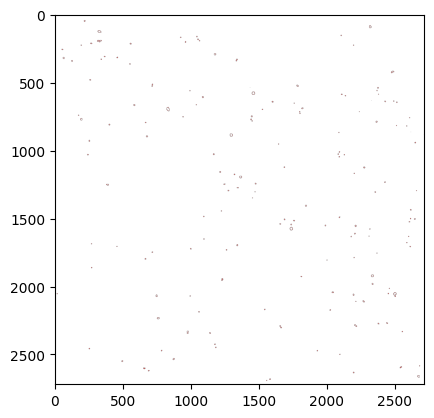

In [48]:

gt_resized = (gt_resized > 0) * 255
gt_resized = np.asarray(gt_resized, dtype="uint8")
print(np.unique(gt_resized))
plt.imshow(gt_resized)

In [ ]:
for i in range(len(gt_hela)):
    gt = skimage.io.imread('/scr/yren/Corrected_HeLa_RPE_GTs/HeLa/' + gt_hela[i])
    imid = gt_hela[i].split('.')[0]
    filename = imid + '.phenotype_outlines.png'
    
    gt_resized = skimage.transform.resize(gt, (2720, 2720))
    gt_resized = (gt_resized > 0) * 255
    gt_resized = np.asarray(gt_resized, dtype="uint8") # PNG, uint8 (0-255)
    skimage.io.imsave(f'/scr/yren/dataset_v3_corrected/HeLa/{filename}', gt_resized)

for j in range(len(gt_rpe1)):
    gt = skimage.io.imread('/scr/yren/Corrected_HeLa_RPE_GTs/RPE1/' + gt_rpe1[j])
    imid = gt_rpe1[j].split('.')[0]
    filename = imid + '.phenotype_outlines.png'
    
    gt_resized = skimage.transform.resize(gt, (2720, 2720))
    gt_resized = (gt_resized > 0) * 255
    gt_resized = np.asarray(gt_resized, dtype="uint8") # PNG, uint8 (0-255)
    skimage.io.imsave(f'/scr/yren/dataset_v3_corrected/RPE1/{filename}', gt_resized)

/tmp/ipykernel_2931059/4194449287.py:9: UserWarning: /scr/yren/dataset_v3_corrected/HeLa/C1-20X_c0_B3_Tile-24.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(f'/scr/yren/dataset_v3_corrected/HeLa/{filename}', gt_resized)
/tmp/ipykernel_2931059/4194449287.py:9: UserWarning: /scr/yren/dataset_v3_corrected/HeLa/C1-20X_c0_B3_Tile-15.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(f'/scr/yren/dataset_v3_corrected/HeLa/{filename}', gt_resized)
/tmp/ipykernel_2931059/4194449287.py:9: UserWarning: /scr/yren/dataset_v3_corrected/HeLa/C1-20X_c0_B3_Tile-5.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(f'/scr/yren/dataset_v3_corrected/HeLa/{filename}', gt_resized)
/tmp/ipykernel_2931059/4194449287.py:19: UserWarning: /scr/yren/dataset_v3_corrected/RPE1/C1-20X_c0_phalloidin_C3_Tile-18.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(f'/scr/yren/dataset_v3_corrected/RPE1/{filename}', gt_resized)
/tmp/ipykernel_2931059/419444

In [51]:
print(gt.shape)
print(gt_resized.shape)

(2992, 2992, 4)
(2720, 2720, 4)


# Cellpose

# Process HeLa Batch

In [52]:
images_dir = "/scr/yren/dataset_v3_corrected/HeLa/"
out_dir = images_dir

file_names = [x for x in os.listdir(images_dir) if x.endswith(".phenotype.tif")]
file_names = [x for x in file_names if not x.startswith('.')]
input_files = [f"{images_dir}{x}" for x in file_names]

imgs = [imread(f) for f in input_files]
nimg = len(imgs)
print(nimg)

model = models.Cellpose(model_type='nuclei')
channels = [0,0]
masks, flows, styles, diams = model.eval(imgs, diameter=None, channels=channels)

output_files = [out_dir + x.replace(".phenotype.tif",".nuclei.tif") for x in file_names]
for i in range(len(masks)):
    skimage.io.imsave(output_files[i], masks[i])

3


/scr/yren/miniconda3/envs/micronuclei-detection/lib/python3.12/site-packages/cellpose/resnet_torch.py:275: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.l

In [14]:
output_files

['/scr/yren/dataset_v3/HeLa/C1-20X_c0_B3_Tile-5.nuclei.tif',
 '/scr/yren/dataset_v3/HeLa/C1-20X_c0_B3_Tile-24.nuclei.tif',
 '/scr/yren/dataset_v3/HeLa/C1-20X_c0_B3_Tile-15.nuclei.tif']

# Fix nuclei masks

In [ ]:
images_dir = "/scr/yren/dataset_v3_corrected/HeLa/"
out_dir = images_dir

file_names = [x for x in os.listdir(images_dir) if x.endswith(".phenotype.tif")]
file_names = [x for x in file_names if not x.startswith('.')]
micron_files = [f"{images_dir}{x.replace('.tif','_outlines.png')}" for x in file_names]
nuclei_files = [out_dir + x.replace(".phenotype.tif",".nuclei.tif") for x in file_names]


total_overlap = 0
for m, n in zip(micron_files, nuclei_files):
    print(n.split("/")[-1])
    
    # Load micronuclei and nuclei masks
    mic_masks = skimage.io.imread(m)
    nuc_masks = skimage.io.imread(n)

    # Prepare micronuclei masks
    edge = mic_masks[:,:,0] > 0 # Use only the red channel, edge annotation only
    mask = scipy.ndimage.binary_fill_holes(edge) ^ edge
    full_mic = mask + edge

    # Dilate micronuclei to obtain extra edges
    d = skimage.morphology.disk(2)
    dilated_obj = skimage.morphology.dilation(full_mic, d)
    dilated_edg = scipy.ndimage.binary_fill_holes(dilated_obj) ^ full_mic

    # Count objects and report differences
    # obj = len(np.unique(skimage.morphology.label(mask)))
    # full_obj = len(np.unique(skimage.morphology.label(full_mic)))
    # dil_obj = len(np.unique(skimage.morphology.label(dilated_obj)))
    # print(f"Without and with edges: {obj}(without) - {full_obj}(with) = {obj - full_obj}(diff)")
    # print(f"With edges plus dilation: {full_obj}(edges) - {dil_obj}(dilated) = {full_obj - dil_obj}(diff)")

    # Find overlaps and remove them
    overlap = np.logical_and(full_mic, nuc_masks)
    total_overlap += np.sum(overlap)
    print("Overlap:",np.sum(overlap))
    clean_nuclei = (nuc_masks>0) ^ overlap
    clean_labels = skimage.morphology.label(clean_nuclei)
    clean_labels = np.asarray(clean_labels, dtype="uint16") # TIFF (0-65535), uint16 recommended.

    # Save result
    skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
    # skimage.io.imsave(n.replace(".nuclei.tif",".extra-edge.tif"), dilated_edg)
    

C1-20X_c0_B3_Tile-5.nuclei.tif
Overlap: 2099
C1-20X_c0_B3_Tile-24.nuclei.tif


/tmp/ipykernel_2931059/75218437.py:44: UserWarning: /scr/yren/dataset_v3_corrected/HeLa/C1-20X_c0_B3_Tile-5.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)


Overlap: 4801
C1-20X_c0_B3_Tile-15.nuclei.tif


/tmp/ipykernel_2931059/75218437.py:44: UserWarning: /scr/yren/dataset_v3_corrected/HeLa/C1-20X_c0_B3_Tile-24.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)


Overlap: 3534


/tmp/ipykernel_2931059/75218437.py:44: UserWarning: /scr/yren/dataset_v3_corrected/HeLa/C1-20X_c0_B3_Tile-15.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)


In [19]:
print("Total overlap in dataset:",total_overlap)

Total overlap in dataset: 14440


# Fix RPE1 batch

## Fix filename

In [ ]:
path = '/scr/yren/dataset_v3/RPE1/'
files = os.listdir(path)
files = [file for file in files if not file.startswith('.')]

for img in files:
    im = skimage.io.imread(path + img)
    
    if 'phenotype_phalloidin_outlines.png' in img:
        save_path = path + img.replace('phenotype_phalloidin_outlines', 'phenotype_outlines')
    elif 'phenotype_phalloidin' in img:
        save_path = path + img.replace('phenotype_phalloidin', 'phenotype')
    skimage.io.imsave(save_path, im)

In [57]:
images_dir = "/scr/yren/dataset_v3_corrected/RPE1/"
out_dir = images_dir

file_names = [x for x in os.listdir(images_dir) if x.endswith(".phenotype.tif")]
file_names = [x for x in file_names if not x.startswith('.')]
input_files = [f"{images_dir}{x}" for x in file_names]
input_files

['/scr/yren/dataset_v3_corrected/RPE1/C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif',
 '/scr/yren/dataset_v3_corrected/RPE1/C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif',
 '/scr/yren/dataset_v3_corrected/RPE1/C1-20X_c0_phalloidin_C3_Tile-44.phenotype.tif']

In [59]:
images_dir = "/scr/yren/dataset_v3_corrected/RPE1/"
out_dir = images_dir

file_names = [x for x in os.listdir(images_dir) if x.endswith(".phenotype.tif")]
file_names = [x for x in file_names if not x.startswith('.')]
input_files = [f"{images_dir}{x}" for x in file_names]

imgs = [imread(f) for f in input_files]
nimg = len(imgs)
print(nimg)

model = models.Cellpose(model_type='nuclei')
channels = [0,0]
masks, flows, styles, diams = model.eval(imgs, diameter=None, channels=channels)

output_files = [out_dir + x.replace(".phenotype.tif",".nuclei.tif") for x in file_names]
for i in range(len(masks)):
    skimage.io.imsave(output_files[i], masks[i])

3


/tmp/ipykernel_2931059/383546362.py:18: UserWarning: /scr/yren/dataset_v3_corrected/RPE1/C1-20X_c0_phalloidin_C3_Tile-18.nuclei.tif is a low contrast image
  skimage.io.imsave(output_files[i], masks[i])
/tmp/ipykernel_2931059/383546362.py:18: UserWarning: /scr/yren/dataset_v3_corrected/RPE1/C1-20X_c0_phalloidin_C3_Tile-15.nuclei.tif is a low contrast image
  skimage.io.imsave(output_files[i], masks[i])
/tmp/ipykernel_2931059/383546362.py:18: UserWarning: /scr/yren/dataset_v3_corrected/RPE1/C1-20X_c0_phalloidin_C3_Tile-44.nuclei.tif is a low contrast image
  skimage.io.imsave(output_files[i], masks[i])


In [61]:
images_dir = "/scr/yren/dataset_v3_corrected/RPE1/"
out_dir = images_dir

file_names = [x for x in os.listdir(images_dir) if x.endswith(".phenotype.tif")]
file_names = [x for x in file_names if not x.startswith('.')]
micron_files = [f"{images_dir}{x.replace('.tif','_outlines.png')}" for x in file_names]
nuclei_files = [out_dir + x.replace(".phenotype.tif",".nuclei.tif") for x in file_names]


total_overlap = 0
for m, n in zip(micron_files, nuclei_files):
    print(n.split("/")[-1])
    
    # Load micronuclei and nuclei masks
    mic_masks = skimage.io.imread(m)
    nuc_masks = skimage.io.imread(n)

    # Prepare micronuclei masks
    edge = mic_masks[:,:,0] > 0 # Use only the red channel, edge annotation only
    mask = scipy.ndimage.binary_fill_holes(edge) ^ edge
    full_mic = mask + edge

    # Dilate micronuclei to obtain extra edges
    d = skimage.morphology.disk(2)
    dilated_obj = skimage.morphology.dilation(full_mic, d)
    dilated_edg = scipy.ndimage.binary_fill_holes(dilated_obj) ^ full_mic

    # Count objects and report differences
    # obj = len(np.unique(skimage.morphology.label(mask)))
    # full_obj = len(np.unique(skimage.morphology.label(full_mic)))
    # dil_obj = len(np.unique(skimage.morphology.label(dilated_obj)))
    # print(f"Without and with edges: {obj}(without) - {full_obj}(with) = {obj - full_obj}(diff)")
    # print(f"With edges plus dilation: {full_obj}(edges) - {dil_obj}(dilated) = {full_obj - dil_obj}(diff)")

    # Find overlaps and remove them
    overlap = np.logical_and(full_mic, nuc_masks)
    total_overlap += np.sum(overlap)
    print("Overlap:",np.sum(overlap))
    clean_nuclei = (nuc_masks>0) ^ overlap
    clean_labels = skimage.morphology.label(clean_nuclei)
    clean_labels = np.asarray(clean_labels, dtype="uint16")

    # Save result
    skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
    # skimage.io.imsave(n.replace(".nuclei.tif",".extra-edge.tif"), dilated_edg)
    

C1-20X_c0_phalloidin_C3_Tile-18.nuclei.tif
Overlap: 2895
C1-20X_c0_phalloidin_C3_Tile-15.nuclei.tif


/tmp/ipykernel_2931059/1450542638.py:44: UserWarning: /scr/yren/dataset_v3_corrected/RPE1/C1-20X_c0_phalloidin_C3_Tile-18.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)


Overlap: 3519
C1-20X_c0_phalloidin_C3_Tile-44.nuclei.tif


/tmp/ipykernel_2931059/1450542638.py:44: UserWarning: /scr/yren/dataset_v3_corrected/RPE1/C1-20X_c0_phalloidin_C3_Tile-15.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)


Overlap: 1676


/tmp/ipykernel_2931059/1450542638.py:44: UserWarning: /scr/yren/dataset_v3_corrected/RPE1/C1-20X_c0_phalloidin_C3_Tile-44.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)


# Example

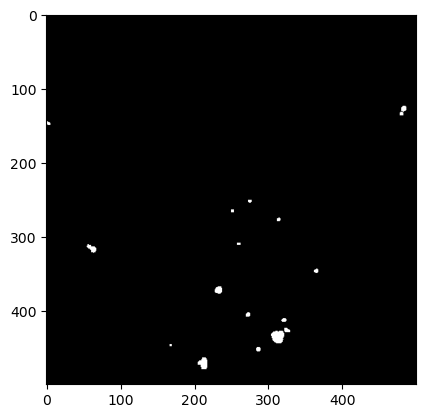

In [21]:
# Load micronuclei and nuclei masks
mic_masks = skimage.io.imread(micron_files[0])
nuc_masks = skimage.io.imread(nuclei_files[0])

edge = mic_masks[:,:,0] > 0 # Use only the red channel
mask = scipy.ndimage.binary_fill_holes(edge) ^ edge
labels = skimage.morphology.label(mask)

full_mic = mask + edge
plt.imshow(full_mic[1000:1500,1000:1500], cmap="gray")

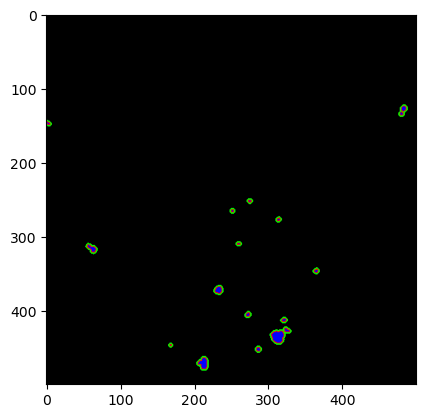

In [22]:
d = skimage.morphology.disk(2)
dilated_obj = skimage.morphology.dilation(full_mic, d)
dilated_edg = scipy.ndimage.binary_fill_holes(dilated_obj) ^ full_mic

edg_mask = np.concatenate([255*edge[:,:,None], 255*dilated_edg[:,:,None], 255*mask[:,:,None]], axis=2)
plt.imshow(edg_mask[1000:1500,1000:1500], cmap="gray")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


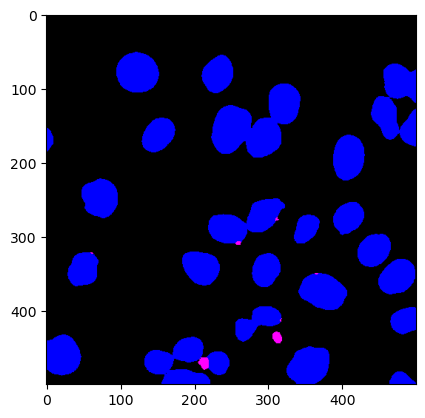

In [25]:
overlap = np.logical_and(dilated_obj, nuc_masks)
view = np.concatenate([255*overlap[:,:,None], np.zeros_like(mask)[:,:,None], 255*nuc_masks[:,:,None]], axis=2)
plt.imshow(view[1000:1500,1000:1500], cmap="gray")

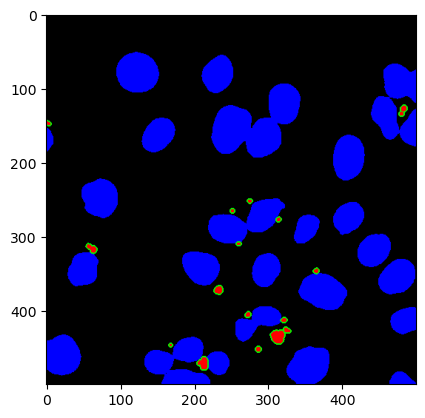

In [24]:
clean_nuclei = (nuc_masks>0) ^ overlap
view = np.concatenate([1.*full_mic[:,:,None], 1*dilated_edg[:,:,None], 1.*clean_nuclei[:,:,None]], axis=2)
plt.imshow(view[1000:1500,1000:1500])